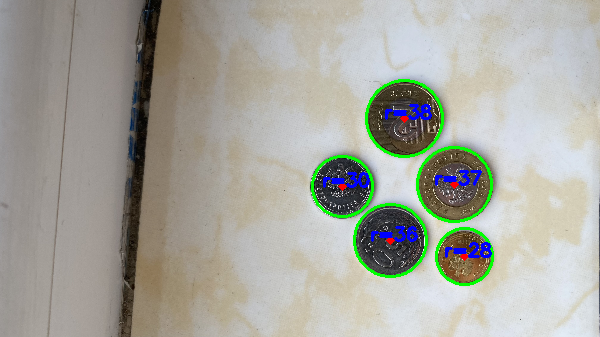

In [ ]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

nazwa_pliku = 'IMG_0406.jpg'
sila_rozmycia = 9
parametr_czulosci = 40

img_org = cv2.imread(nazwa_pliku)

scale = 600 / float(img_org.shape[1])
nowa_wysokosc = int(img_org.shape[0] * scale)

img = cv2.resize(img_org, (600, nowa_wysokosc))
output = img.copy()


gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
gray_blurred = cv2.medianBlur(gray, sila_rozmycia)

circles = cv2.HoughCircles(
gray_blurred,
cv2.HOUGH_GRADIENT,
dp=1,
minDist=40,
param1=50,
param2=parametr_czulosci,
minRadius=20,
maxRadius=80
)

circles_rounded = np.round(circles[0, :]).astype("int")

for i, (x, y, r) in enumerate(circles_rounded):
    cv2.circle(output, (x, y), r, (0, 255, 0), 2)
    cv2.circle(output, (x, y), 2, (0, 0, 255), 3)
    tekst_na_zdjeciu = f"r={r}"
    cv2.putText(output, tekst_na_zdjeciu, (x - 20, y),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 2)
cv2_imshow(output)
#2 37/38 , 50 34, 20 31, 1 27

R=32px -> SIFT zawiódł (7 pkt). Zgaduję po rozmiarze: 50 gr
R=33px -> Odrzucono inne. SIFT potwierdza: 50 gr (Punkty: 10)
R=28px -> Odrzucono inne. SIFT potwierdza: 1 gr (Punkty: 12)
RAZEM W SKARBONCE: 1.01 ZŁ


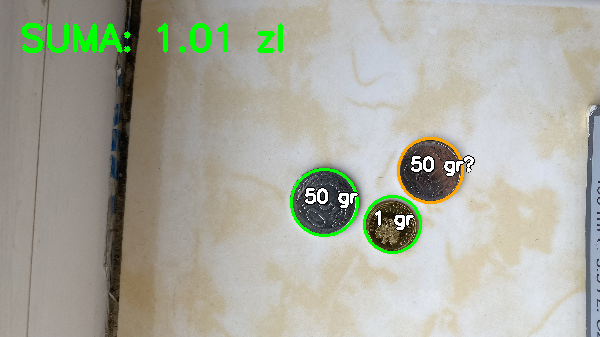

In [ ]:


wzorce_info = {
    "0.5Orzel.jpg": "50 gr",
    "0.5Reszka.jpg": "50 gr",
    "2Orzel.jpg": "2 zl",
    "2Reszka.jpg": "2 zl",
    "0.01Orzel.jpg": "1 gr",
    "0.01Reszka.jpg": "1 gr",
    "0.2Orzel.jpg": "20 gr",
    "0.2Reszka.jpg": "20 gr",
    "0.5Orzel.jpg": "50 gr",
    "0.5Reszka.jpg": "50 gr",
}

wartosci_nominalow = {
    "2 zl": 2.00, "50 gr": 0.50, "20 gr": 0.20, "1 gr": 0.01
}

baza_deskryptorow = {}
wymiar_wzorca = 300

sift = cv2.SIFT_create()
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))

maska_sift = np.zeros((wymiar_wzorca, wymiar_wzorca), dtype=np.uint8)
cv2.circle(maska_sift, (wymiar_wzorca//2, wymiar_wzorca//2), (wymiar_wzorca//2)-5, 255, -1)

for nazwa_pliku, nominal in wzorce_info.items():
    img_surowe = cv2.imread(nazwa_pliku)

    scale = 1000 / float(img_surowe.shape[1])
    img_surowe = cv2.resize(img_surowe, (1000, int(img_surowe.shape[0] * scale)))

    gray = cv2.cvtColor(img_surowe, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (15, 15), 0)

    _, thresh = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    kontury, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    najwiekszy_kontur = max(kontury, key=cv2.contourArea)
    ((x, y), promien) = cv2.minEnclosingCircle(najwiekszy_kontur)
    x, y, promien = int(x), int(y), int(promien)

    margines = 5
    r_ciecia = promien + margines
    y1, y2 = max(0, y - r_ciecia), min(img_surowe.shape[0], y + r_ciecia)
    x1, x2 = max(0, x - r_ciecia), min(img_surowe.shape[1], x + r_ciecia)

    wycieta_moneta = img_surowe[y1:y2, x1:x2]
    wycieta_moneta = cv2.resize(wycieta_moneta, (wymiar_wzorca, wymiar_wzorca))

    gray_wzorzec = cv2.cvtColor(wycieta_moneta, cv2.COLOR_BGR2GRAY)
    gray_clahe = clahe.apply(gray_wzorzec)
    kp, desc = sift.detectAndCompute(gray_clahe, mask=maska_sift)

    baza_deskryptorow[nazwa_pliku] = {
        "nominal": nominal,
        "deskryptory": desc
    }

nazwa_glownego_zdjecia = 'IMG_0408.jpg'
img_glowne = cv2.imread(nazwa_glownego_zdjecia)

scale = 600 / float(img_glowne.shape[1])
nowa_wysokosc = int(img_glowne.shape[0] * scale)
img_glowne = cv2.resize(img_glowne, (600, nowa_wysokosc))

gray_glowne = cv2.cvtColor(img_glowne, cv2.COLOR_BGR2GRAY)
gray_blurred = cv2.medianBlur(gray_glowne, 7)

circles = cv2.HoughCircles(
    gray_blurred, cv2.HOUGH_GRADIENT, dp=1, minDist=40,
    param1=50, param2=35, minRadius=15, maxRadius=100
)

circles_rounded = np.round(circles[0, :]).astype("int")
bf = cv2.BFMatcher()
suma_calkowita = 0.0

for i, (x, y, r) in enumerate(circles_rounded):
    kandydaci = []
    if r >= 36:
        kandydaci = ["2 zl"]
    elif r >= 32 and r < 36:
        kandydaci = ["50 gr"]
    elif r >= 29 and r < 32:
        kandydaci = ["20 gr"]
    else:
        kandydaci = ["1 gr"]

    y1, y2 = max(0, y-r), min(img_glowne.shape[0], y+r)
    x1, x2 = max(0, x-r), min(img_glowne.shape[1], x+r)

    wycinek_monety = img_glowne[y1:y2, x1:x2]

    if wycinek_monety.shape[0] == 0 or wycinek_monety.shape[1] == 0:
        continue

    wycinek_monety = cv2.resize(wycinek_monety, (wymiar_wzorca, wymiar_wzorca))
    gray_wycinek = cv2.cvtColor(wycinek_monety, cv2.COLOR_BGR2GRAY)
    gray_wycinek_clahe = clahe.apply(gray_wycinek)

    kp_nieznana, desc_nieznana = sift.detectAndCompute(gray_wycinek_clahe, mask=maska_sift)

    najlepszy_wynik = 0
    najlepszy_nominal = "Nieznana"

    for nazwa_wzorca, dane_wzorca in baza_deskryptorow.items():
        if dane_wzorca["nominal"] not in kandydaci:
            continue

        desc_wzorzec = dane_wzorca["deskryptory"]
        matches = bf.knnMatch(desc_wzorzec, desc_nieznana, k=2)

        dobre_dopasowania = []
        for m, n in matches:
            if m.distance < 0.75 * n.distance:
                dobre_dopasowania.append(m)

        wynik = len(dobre_dopasowania)

        if wynik > najlepszy_wynik:
            najlepszy_wynik = wynik
            najlepszy_nominal = dane_wzorca["nominal"]

    prog_pewnosci = 8
    cv2.circle(img_glowne, (x, y), r, (0, 255, 0), 2)

    if najlepszy_wynik >= prog_pewnosci:
        suma_calkowita += wartosci_nominalow[najlepszy_nominal]
        opis = najlepszy_nominal
        print(f"R={r}px -> Odrzucono inne. SIFT potwierdza: {najlepszy_nominal} (Punkty: {najlepszy_wynik})")
    else:
        opis = kandydaci[0] + "?"
        suma_calkowita += wartosci_nominalow[kandydaci[0]]
        print(f"R={r}px -> SIFT zawiódł ({najlepszy_wynik} pkt). Zgaduję po rozmiarze: {kandydaci[0]}")
        cv2.circle(img_glowne, (x, y), r, (0, 165, 255), 2) # Pomarańczowy obrys dla zgadywania

    cv2.putText(img_glowne, opis, (x - 20, y), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,0,0), 4)
    cv2.putText(img_glowne, opis, (x - 20, y), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255,255,255), 2)


print(f"RAZEM W SKARBONCE: {suma_calkowita:.2f} ZŁ")
cv2.putText(img_glowne, f"SUMA: {suma_calkowita:.2f} zl", (20, 50), cv2.FONT_HERSHEY_SIMPLEX, 1.2, (0, 255, 0), 3)

cv2_imshow(img_glowne)